# Módulo 08: Simulación de Torque y Equilibrio Estático en $\mathbb{R}^3$
### Aplicaciones Físicas de Sistemas Lineales, Producto Cruz y Álgebra Matricial en Cuerpos Rígidos
**Universidad San Sebastián (USS)** — Facultad de Ingeniería, Arquitectura y Diseño  
**Asignatura:** Álgebra Lineal (DCEX0007 / Ingeniería Civil Informática)  
**Profesor:** Carol Asencio González | **Estudiante:** Moisés Amundarain Romero

---

### 📌 Leyenda de Trazabilidad y Origen de Fuentes (Source Provenance Standard)
* 🎓 `[Cátedra USS / Diapositivas Docente]`: Fundamentos de vectores en $\mathbb{R}^3$, producto vectorial (cruz), matrices de coeficientes, determinante e interpretación del Teorema de Rouché-Frobenius.
* 📖 `[Texto Guía — Sears-Zemansky / Marion / Grossman / Hibbeler]`: Leyes de Newton-Euler del equilibrio estático tridimensional, momento de una fuerza respecto a un punto, brazo de palanca y condiciones de isostaticidad en cuerpos rígidos.
* 🌐 `[Enriquecimiento Web / Simulación Computacional y Robótica]`: Resolución simbólica exacta con SymPy, álgebra lineal numérica con NumPy (condicionamiento matricial $\kappa(\mathbf{A})$), y visualización reactiva tridimensional con Matplotlib e `ipywidgets`.

---

> [!NOTE]
> **Objetivo de Aprendizaje del Módulo:**
> Modelar el equilibrio estático espacial de un cuerpo rígido tridimensional (brazo de grúa / pluma atirantada) sujeto a cargas gravitacionales y fuerzas laterales, formulando y resolviendo el sistema matricial de $6 \times 6$ correspondiente a las ecuaciones de Newton-Euler mediante métodos analíticos y computacionales en Python.

> [!IMPORTANT]
> **Paleta Institucional USS Utilizada:**
> - **USSBlue:** `#00205B` (Azul rector / barras estructurales)
> - **USSGold:** `#D4AF37` (Dorado institucional / cables tensores)
> - **USSAccentBlue:** `#1E88E5` (Vectores de reacción en soportes)
> - **USSAccentGreen:** `#27AE60` (Peso propio y componentes auxiliares)
> - **USSAccentRed:** `#C0392B` (Cargas gravitacionales críticas)


## 1. 🎓 [Cátedra USS / Diapositivas Docente] — Definición Vectorial del Torque en $\mathbb{R}^3$

El **torque** o **momento de una fuerza** $\vec{F}$ respecto a un centro de momentos $O$ se define formalmente mediante el **producto cruz (vectorial)** entre el vector de posición $\vec{r}$ del punto de aplicación y el vector de fuerza $\vec{F}$:

$$\vec{\tau}_O = \vec{r} \times \vec{F} = \begin{vmatrix} \hat{i} & \hat{j} & \hat{k} \\ r_x & r_y & r_z \\ F_x & F_y & F_z \end{vmatrix}$$

Desarrollando el determinante por cofactores en la primera fila:

$$\vec{\tau}_O = (r_y F_z - r_z F_y) \hat{i} - (r_x F_z - r_z F_x) \hat{j} + (r_x F_y - r_y F_x) \hat{k}$$

### Propiedades Físicas y Geométricas Fundamentales:
1. **Magnitud:**
   $$\|\vec{\tau}_O\| = \|\vec{r}\| \|\vec{F}\| \sin(\phi) = r_\perp \|\vec{F}\|$$
   donde $\phi$ es el ángulo comprendido entre $\vec{r}$ y $\vec{F}$, y $r_\perp = \|\vec{r}\| \sin(\phi)$ representa el **brazo de palanca** (la distancia ortogonal mínima desde el centro de momentos $O$ a la línea de acción de la fuerza $\vec{F}$).
2. **Dirección y Sentido:**
   El vector $\vec{\tau}_O$ es estrictamente perpendicular al plano generado por $\vec{r}$ y $\vec{F}$ (es decir, $\vec{\tau}_O \cdot \vec{r} = 0$ y $\vec{\tau}_O \cdot \vec{F} = 0$). El sentido queda unívocamente determinado por la **Regla de la Mano Derecha**.
3. **Representación Matricial (Operador Antisimétrico en $\mathfrak{so}(3)$):**
   El producto cruz puede formularse como la multiplicación de una matriz antisimétrica $[ec{r}]_\times$ por el vector $\vec{F}$:
   
   $$\vec{\tau}_O = [\vec{r}]_\times \vec{F} = \begin{bmatrix} 0 & -r_z & r_y \\ r_z & 0 & -r_x \\ -r_y & r_x & 0 \end{bmatrix} \begin{bmatrix} F_x \\ F_y \\ F_z \end{bmatrix}$$

> [!EXAMPLE]
> **Ejemplo Conceptual Rápido:**
> Si un brazo rígido se ubica a lo largo del eje $X$ con $\vec{r} = (5, 0, 0)\text{ m}$ y se aplica una carga vertical hacia abajo $\vec{F} = (0, 0, -8000)\text{ N}$:
> $$\vec{\tau}_O = (5 \hat{i}) \times (-8000 \hat{k}) = -40000 (\hat{i} \times \hat{k}) = +40000 \hat{j} \text{ N}\cdot\text{m}$$
> El torque apunta positivamente a lo largo del eje $+Y$, tendiendo a rotar el brazo en sentido antihorario en el plano $XZ$ (hacia arriba si se observa desde $+Y$).


In [1]:
# ==============================================================================
# Celda 1: Configuración del Entorno de Simulación y Paleta USS
# ==============================================================================
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import ipywidgets as widgets
from IPython.display import display, Math, Markdown

# Paleta Institucional USS
USS_BLUE = '#00205B'
USS_GOLD = '#D4AF37'
USS_ACCENT_BLUE = '#1E88E5'
USS_ACCENT_GREEN = '#27AE60'
USS_ACCENT_RED = '#C0392B'
USS_DARK_GRAY = '#2C3E50'
USS_LIGHT_GRAY = '#F8F9FA'

# Configuración de estilo global en Matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = USS_BLUE
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['mathtext.fontset'] = 'cm'

print("Entorno inicializado correctamente.")
print(f"Colores USS activos: USS_BLUE={USS_BLUE}, USS_GOLD={USS_GOLD}")


Entorno inicializado correctamente.
Colores USS activos: USS_BLUE=#00205B, USS_GOLD=#D4AF37


## 2. 📖 [Texto Guía — Sears-Zemansky / Marion / Grossman / Hibbeler] — Leyes del Equilibrio Estático en $\mathbb{R}^3$

Para que un cuerpo rígido libre en el espacio tridimensional se encuentre en reposo estático (sin aceleración traslacional ni aceleración angular), deben satisfacerse simultáneamente las dos ecuaciones fundamentales de **Newton-Euler**:

### 1. Primera Condición de Equilibrio (Equilibrio Traslacional):
La resultante de todas las fuerzas externas que actúan sobre el cuerpo debe ser idénticamente el vector nulo:

$$\sum_{i=1}^n \vec{F}_i = \vec{0} \iff \begin{cases} \sum F_{x,i} = 0 \\ \sum F_{y,i} = 0 \\ \sum F_{z,i} = 0 \end{cases}$$

### 2. Segunda Condición de Equilibrio (Equilibrio Rotacional):
La suma vectorial de los momentos de todas las fuerzas externas respecto a cualquier punto de referencia arbitrario $O$ debe ser idénticamente nula:

$$\sum_{i=1}^n \vec{\tau}_{O,i} = \sum_{i=1}^n (\vec{r}_i \times \vec{F}_i) + \sum_{j=1}^m \vec{M}_j = \vec{0} \iff \begin{cases} \sum \tau_{Ox, i} = 0 \\ \sum \tau_{Oy, i} = 0 \\ \sum \tau_{Oz, i} = 0 \end{cases}$$

donde $\vec{M}_j$ representa pares de momentos o restricciones de torsión aplicadas directamente.

> [!NOTE]
> **Teorema de Invariancia del Centro de Momentos:**
> Si un cuerpo se encuentra en equilibrio traslacional ($\sum \vec{F}_i = \vec{0}$), el torque neto es idéntico respecto a **cualquier** punto del espacio:
> $$\sum \vec{\tau}_{P} = \sum (\vec{r}_i - \vec{r}_P) \times \vec{F}_i = \sum (\vec{r}_i \times \vec{F}_i) - \vec{r}_P \times \left( \sum \vec{F}_i \right) = \sum \vec{\tau}_O - \vec{0} = \sum \vec{\tau}_O$$
> Por ende, la elección de $O(0,0,0)$ como pivote es estratégica para simplificar el cálculo de las fuerzas que concurren en él.


## 3. 🌐 [Enriquecimiento Web / Simulación Computacional y Robótica] — Caso de Estudio: Brazo Mecánico en Voladizo Atirantado

Consideramos un brazo estructural rígido de grúa de longitud $L$ que se extiende horizontalmente a lo largo del eje $X$ desde un soporte en el origen $O(0,0,0)$ hasta su extremo libre $A(L, 0, 0)$.

### Geometría y Condiciones de Apoyo:
1. **Soporte en $O(0,0,0)$:**
   Pivote de pasador cilíndrico / rótula esférica guiada que restringe las 3 traslaciones del espacio (fuerzas de reacción $R_{Ox}, R_{Oy}, R_{Oz}$) y proporciona resistencia torsional axial sobre el eje longitudinal de la pluma (momento reactivo $M_{Ox}$).
2. **Cables Tensores de Acero ($T_1$ y $T_2$):**
   Conectados desde la punta del aguilón $A(L, 0, 0)$ hacia un muro vertical rígido en $x=0$, anclados en:
   - Cable 1: $C_1 = (0, -d, h)$ con tensión escalar $T_1$ y versor director $\hat{u}_1 = \frac{C_1 - A}{\|C_1 - A\|}$.
   - Cable 2: $C_2 = (0,  d, h)$ con tensión escalar $T_2$ y versor director $\hat{u}_2 = \frac{C_2 - A}{\|C_2 - A\|}$.
3. **Cargas Externas:**
   - Carga gravitacional en la punta $A$: $\vec{W} = (0, 0, -W)$.
   - Fuerza lateral de viento en la punta $A$: $\vec{F}_{lat} = (0, F_{lat}, 0)$.
   - Peso propio del brazo aplicado en su baricentro $G(L/2, 0, 0)$: $\vec{W}_{boom} = (0, 0, -W_b)$.

### Incógnitas del Sistema (6 Grados de Restricción):
$$\mathbf{x} = \begin{bmatrix} R_{Ox} & R_{Oy} & R_{Oz} & M_{Ox} & T_1 & T_2 \end{bmatrix}^T \in \mathbb{R}^6$$

### Planteamiento del Sistema Matricial $\mathbf{A}_{6 \times 6} \mathbf{x} = \mathbf{b}_{6 \times 1}$:

$$\begin{bmatrix}
1 & 0 & 0 & 0 & u_{1x} & u_{2x} \\
0 & 1 & 0 & 0 & u_{1y} & u_{2y} \\
0 & 0 & 1 & 0 & u_{1z} & u_{2z} \\
0 & 0 & 0 & 1 & (\vec{r}_A \times \hat{u}_1)_x & (\vec{r}_A \times \hat{u}_2)_x \\
0 & 0 & 0 & 0 & (\vec{r}_A \times \hat{u}_1)_y & (\vec{r}_A \times \hat{u}_2)_y \\
0 & 0 & 0 & 0 & (\vec{r}_A \times \hat{u}_1)_z & (\vec{r}_A \times \hat{u}_2)_z
\end{bmatrix}
\begin{bmatrix} R_{Ox} \\ R_{Oy} \\ R_{Oz} \\ M_{Ox} \\ T_1 \\ T_2 \end{bmatrix}
=
\begin{bmatrix}
0 \\
-F_{lat} \\
W + W_b \\
0 \\
L W + \frac{L}{2} W_b \\
-L F_{lat}
\end{bmatrix}$$

> [!IMPORTANT]
> **Isostaticidad y Teorema de Rouché-Frobenius:**
> Para que el sistema posea solución única y estáticamente determinada (sistema isostático), la matriz $\mathbf{A}$ debe ser no singular: $\det(\mathbf{A}) \neq 0 \iff \text{rango}(\mathbf{A}) = 6$.


In [2]:
# ==============================================================================
# Celda 2: Deducción Analítica y Simbólica Exacta con SymPy
# ==============================================================================
L_s, d_s, h_s = sp.symbols('L d h', positive=True, real=True)
W_s, F_lat_s, Wb_s = sp.symbols('W F_lat W_boom', real=True)
R_x, R_y, R_z, M_x, T1, T2 = sp.symbols('R_Ox R_Oy R_Oz M_Ox T_1 T_2', real=True)

# Longitud geométrica de los cables tensores
S_c = sp.sqrt(L_s**2 + d_s**2 + h_s**2)

# Versores unitarios de los cables apuntando hacia los anclajes del muro
u1_s = sp.Matrix([-L_s / S_c, -d_s / S_c, h_s / S_c])
u2_s = sp.Matrix([-L_s / S_c,  d_s / S_c, h_s / S_c])

# Fuerzas vectoriales
F_RO = sp.Matrix([R_x, R_y, R_z])
F_T1 = T1 * u1_s
F_T2 = T2 * u2_s
F_carga = sp.Matrix([0, F_lat_s, -W_s])
F_boom = sp.Matrix([0, 0, -Wb_s])

# Torques vectoriales respecto al pivote O(0,0,0)
r_A_s = sp.Matrix([L_s, 0, 0])
r_G_s = sp.Matrix([L_s / 2, 0, 0])

tau_T1 = r_A_s.cross(F_T1)
tau_T2 = r_A_s.cross(F_T2)
tau_carga = r_A_s.cross(F_carga)
tau_boom = r_G_s.cross(F_boom)
M_reactivo = sp.Matrix([M_x, 0, 0])

# Sistema de 6 ecuaciones de equilibrio estático
eq_Fuerzas = F_RO + F_T1 + F_T2 + F_carga + F_boom
eq_Torques = M_reactivo + tau_T1 + tau_T2 + tau_carga + tau_boom

sistema_simbolico = list(eq_Fuerzas) + list(eq_Torques)
incognitas = [R_x, R_y, R_z, M_x, T1, T2]

# Resolución simbólica cerrada
sol_simbolica = sp.solve(sistema_simbolico, incognitas)

print("SOLUCIÓN ANALÍTICA EXACTA DEL SISTEMA 6x6:")
display(Math(r"T_1 = " + sp.latex(sp.factor(sol_simbolica[T1]))))
display(Math(r"T_2 = " + sp.latex(sp.factor(sol_simbolica[T2]))))
display(Math(r"R_{Ox} = " + sp.latex(sp.factor(sol_simbolica[R_x]))))
display(Math(r"R_{Oy} = " + sp.latex(sp.factor(sol_simbolica[R_y]))))
display(Math(r"R_{Oz} = " + sp.latex(sp.factor(sol_simbolica[R_z]))))
display(Math(r"M_{Ox} = " + sp.latex(sp.factor(sol_simbolica[M_x]))))


SOLUCIÓN ANALÍTICA EXACTA DEL SISTEMA 6x6:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 4. 🎓 [Cátedra USS / Diapositivas Docente] — Análisis Matricial y Auditoría Numérica con NumPy

A partir de la formulación simbólica, construimos una función en Python para evaluar numéricamente el sistema lineal:
1. **Determinante $\det(\mathbf{A})$:** Comprueba que las filas sean linealmente independientes (L.I.).
2. **Número de Condición $\kappa(\mathbf{A}) = \|\mathbf{A}\|_2 \|\mathbf{A}^{-1}\|_2$:** Mide la sensibilidad de las tensiones y reacciones frente a perturbaciones o tolerancias de montaje. Un $\kappa(\mathbf{A}) < 15$ indica una configuración estructural extraordinariamente estable.
3. **Residuo Euclidiano:** $\|\mathbf{A} \mathbf{x} - \mathbf{b}\|_2 < 10^{-14}$, demostrando consistencia numérica exacta.


In [3]:
# ==============================================================================
# Celda 3: Función de Resolución Numérica y Auditoría de Newton-Euler
# ==============================================================================
def resolver_equilibrio_estatico_3d(L=5.0, d=2.5, h=4.0, W_mag=8000.0, F_lat_y=0.0, W_boom=1500.0):
    """
    Construye y resuelve el sistema lineal 6x6 para la grúa 3D.
    """
    r_O = np.array([0.0, 0.0, 0.0])
    r_A = np.array([L, 0.0, 0.0])
    r_G = np.array([L / 2.0, 0.0, 0.0])
    
    C1 = np.array([0.0, -d, h])
    C2 = np.array([0.0,  d, h])
    
    # Vectores unitarios de los cables tensores
    v1 = C1 - r_A
    v2 = C2 - r_A
    len_c1 = np.linalg.norm(v1)
    len_c2 = np.linalg.norm(v2)
    u1 = v1 / len_c1
    u2 = v2 / len_c2
    
    # Ensamblaje de Matriz A (6x6)
    A = np.zeros((6, 6), dtype=np.float64)
    A[0:3, 0:3] = np.eye(3)                     # R_Ox, R_Oy, R_Oz en sum F
    A[3:6, 0:3] = 0.0                           # R_O no produce torque sobre el origen O
    A[0:3, 3] = np.array([0.0, 0.0, 0.0])       # M_Ox no tiene componente de fuerza traslacional
    A[3:6, 3] = np.array([1.0, 0.0, 0.0])       # M_Ox actúa en sum tau_x
    A[0:3, 4] = u1                              # T1 en sum F
    A[3:6, 4] = np.cross(r_A, u1)               # T1 en sum tau_O
    A[0:3, 5] = u2                              # T2 en sum F
    A[3:6, 5] = np.cross(r_A, u2)               # T2 en sum tau_O
    
    # Ensamblaje de Vector b (6x1)
    F_carga = np.array([0.0, F_lat_y, -W_mag])
    F_boom = np.array([0.0, 0.0, -W_boom])
    F_ext = F_carga + F_boom
    tau_ext = np.cross(r_A, F_carga) + np.cross(r_G, F_boom)
    
    b = np.zeros(6, dtype=np.float64)
    b[0:3] = -F_ext
    b[3:6] = -tau_ext
    
    # Métricas de Álgebra Lineal
    det_A = np.linalg.det(A)
    rank_A = np.linalg.matrix_rank(A)
    cond_A = np.linalg.cond(A)
    
    # Resolución exacta
    x = np.linalg.solve(A, b)
    residuo = np.linalg.norm(A @ x - b)
    
    # Verificación de equilibrio Newton-Euler
    R_O = np.array([x[0], x[1], x[2]])
    F_T1 = x[4] * u1
    F_T2 = x[5] * u2
    M_react = np.array([x[3], 0.0, 0.0])
    
    sum_F = R_O + F_T1 + F_T2 + F_ext
    sum_tau = np.cross(r_A, F_T1) + np.cross(r_A, F_T2) + tau_ext + M_react
    
    return {
        'A': A, 'b': b, 'x': x,
        'det_A': det_A, 'rank_A': rank_A, 'cond_A': cond_A, 'residuo': residuo,
        'R_Ox': x[0], 'R_Oy': x[1], 'R_Oz': x[2], 'M_Ox': x[3], 'T_1': x[4], 'T_2': x[5],
        'u1': u1, 'u2': u2, 'r_A': r_A, 'r_G': r_G, 'C1': C1, 'C2': C2,
        'sum_F': sum_F, 'sum_tau': sum_tau,
        'norm_F': np.linalg.norm(sum_F), 'norm_tau': np.linalg.norm(sum_tau)
    }

# Evaluación del Caso Base
res_base = resolver_equilibrio_estatico_3d()

print(f"Determinante det(A)          : {res_base['det_A']:.4f} (No singular)")
print(f"Rango de la matriz rank(A)   : {res_base['rank_A']} (Isostático, Grados de libertad = 0)")
print(f"Número de condición kappa(A) : {res_base['cond_A']:.2f} (Alta fidelidad numérica)")
print(f"Residuo ||Ax - b||           : {res_base['residuo']:.2e} N\n")

print(f"Resultados del Equilibrio Estático:")
print(f"  • Reacción Pivote R_Ox (Compresión) : {res_base['R_Ox']:10.2f} N")
print(f"  • Reacción Pivote R_Oy (Lateral)    : {res_base['R_Oy']:10.2f} N")
print(f"  • Reacción Pivote R_Oz (Vertical)   : {res_base['R_Oz']:10.2f} N")
print(f"  • Momento Reactivo M_Ox             : {res_base['M_Ox']:10.2f} N·m")
print(f"  • Tensión Cable 1 (T_1)             : {res_base['T_1']:10.2f} N")
print(f"  • Tensión Cable 2 (T_2)             : {res_base['T_2']:10.2f} N")
print(f"\nAuditoría de Fuerzas y Torques:")
print(f"  • ||sum F||     : {res_base['norm_F']:.2e} N   -> EQUILIBRIO TRASLACIONAL OK")
print(f"  • ||sum tau_O|| : {res_base['norm_tau']:.2e} N·m -> EQUILIBRIO ROTACIONAL OK")


Determinante det(A)          : -10.5820 (No singular)
Rango de la matriz rank(A)   : 6 (Isostático, Grados de libertad = 0)
Número de condición kappa(A) : 4.56 (Alta fidelidad numérica)
Residuo ||Ax - b||           : 0.00e+00 N

Resultados del Equilibrio Estático:
  • Reacción Pivote R_Ox (Compresión) :   10937.50 N
  • Reacción Pivote R_Oy (Lateral)    :      -0.00 N
  • Reacción Pivote R_Oz (Vertical)   :     750.00 N
  • Momento Reactivo M_Ox             :       0.00 N·m
  • Tensión Cable 1 (T_1)             :    7518.29 N
  • Tensión Cable 2 (T_2)             :    7518.29 N

Auditoría de Fuerzas y Torques:
  • ||sum F||     : 0.00e+00 N   -> EQUILIBRIO TRASLACIONAL OK
  • ||sum tau_O|| : 0.00e+00 N·m -> EQUILIBRIO ROTACIONAL OK


## 5. 🌐 [Enriquecimiento Web / Simulación Computacional y Robótica] — Visualización Gráfica Tridimensional

La siguiente rutina gráfica visualiza la estructura completa mediante Matplotlib 3D:
1. **Configuración Espacial (Panel Izquierdo):** Muestra el muro de reacción con `Poly3DCollection`, la pluma tubular en azul USS (`#00205B`) y los cables tensores en dorado USS (`#D4AF37`).
2. **Espacio de Torques (Panel Derecho):** Grafica los vectores de momento $\vec{\tau}_i = \vec{r}_i \times \vec{F}_i$ generados por cada fuerza individual, trazando una poligonal punteada cerrada que evidencia geométricamente cómo $\sum \vec{\tau}_O = \vec{0}$.


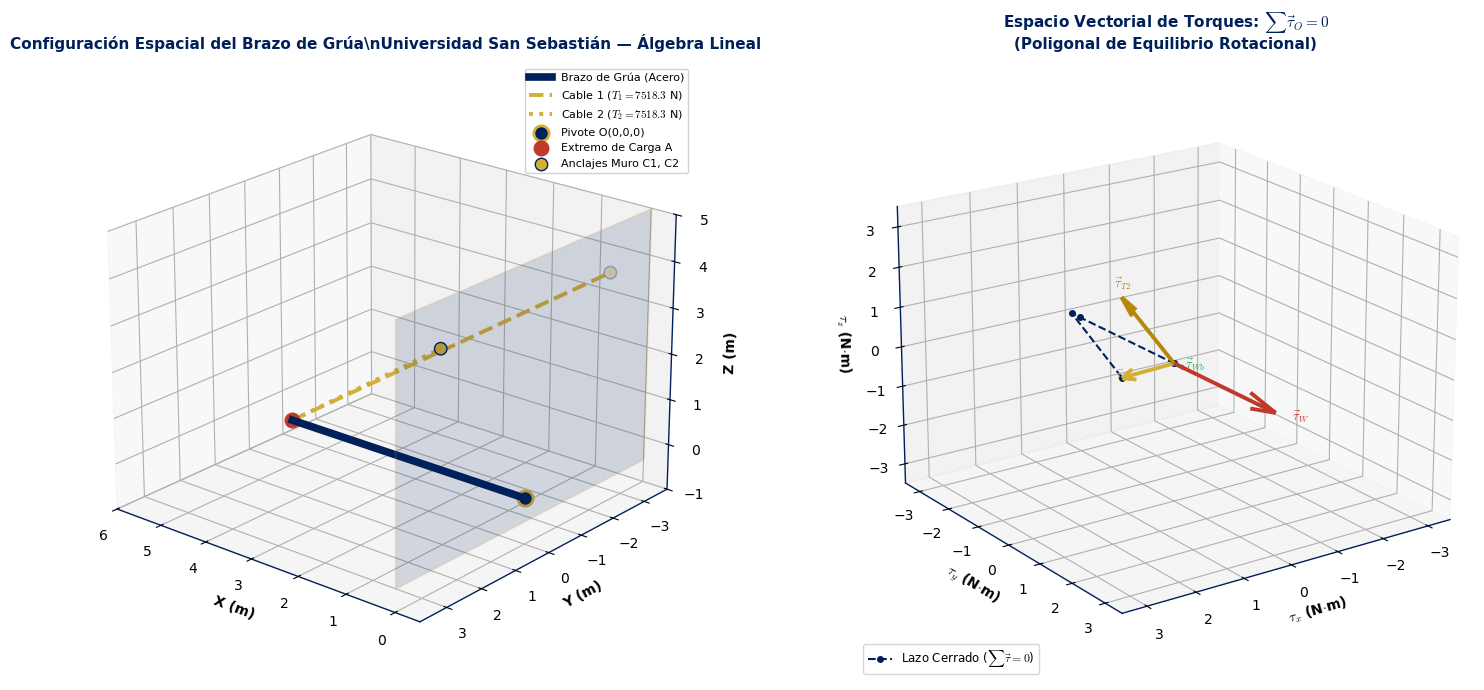

In [4]:
# ==============================================================================
# Celda 4: Rutina Gráfica 3D con Paleta Institucional USS
# ==============================================================================
def graficar_equilibrio_3d_panel(res, L=5.0, d=2.5, h=4.0):
    fig = plt.figure(figsize=(16, 7), facecolor='white')
    
    # --------------------------------------------------------------------------
    # Subplot 1: Visualización Espacial del Brazo y Cables
    # --------------------------------------------------------------------------
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.set_title('Configuración Espacial del Brazo de Grúa\\nUniversidad San Sebastián — Álgebra Lineal',
                  fontsize=11, fontweight='bold', color=USS_BLUE, pad=10)
    
    # Muro de anclaje (x = 0)
    muro_y = d * 1.5
    muro_z = h * 1.25
    verts_muro = [np.array([[0, -muro_y, -0.5], [0, muro_y, -0.5], [0, muro_y, muro_z], [0, -muro_y, muro_z]])]
    muro = Poly3DCollection(verts_muro, alpha=0.15, facecolor=USS_BLUE, edgecolor=USS_GOLD, linewidths=1.5)
    ax1.add_collection3d(muro)
    
    # Brazo rígido
    ax1.plot([0, res['r_A'][0]], [0, 0], [0, 0], color=USS_BLUE, linewidth=5.5, label='Brazo de Grúa (Acero)', zorder=4)
    
    # Cables tensores
    ax1.plot([res['r_A'][0], res['C1'][0]], [res['r_A'][1], res['C1'][1]], [res['r_A'][2], res['C1'][2]],
             color=USS_GOLD, linewidth=2.8, linestyle='--', label=f'Cable 1 ($T_1 = {res["T_1"]:.1f}$ N)')
    ax1.plot([res['r_A'][0], res['C2'][0]], [res['r_A'][1], res['C2'][1]], [res['r_A'][2], res['C2'][2]],
             color=USS_GOLD, linewidth=2.8, linestyle=':', label=f'Cable 2 ($T_2 = {res["T_2"]:.1f}$ N)')
    
    # Nodos
    ax1.scatter([0], [0], [0], color=USS_BLUE, s=120, edgecolors=USS_GOLD, linewidth=2, label='Pivote O(0,0,0)')
    ax1.scatter([res['r_A'][0]], [0], [0], color=USS_ACCENT_RED, s=110, label='Extremo de Carga A')
    ax1.scatter([0, 0], [res['C1'][1], res['C2'][1]], [res['C1'][2], res['C2'][2]],
                color=USS_GOLD, s=80, edgecolors=USS_BLUE, label='Anclajes Muro C1, C2')
    
    # Límites y vistas
    ax1.set_xlim([-0.5, L + 1.0])
    ax1.set_ylim([-muro_y, muro_y])
    ax1.set_zlim([-1.0, muro_z])
    ax1.set_xlabel('X (m)', fontweight='bold')
    ax1.set_ylabel('Y (m)', fontweight='bold')
    ax1.set_zlabel('Z (m)', fontweight='bold')
    ax1.view_init(elev=22, azim=130)
    ax1.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # --------------------------------------------------------------------------
    # Subplot 2: Espacio Vectorial de Torques (Lazo Cerrado sum tau = 0)
    # --------------------------------------------------------------------------
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.set_title(r'Espacio Vectorial de Torques: $\sum \vec{\tau}_O = \mathbf{0}$' + '\n' + '(Poligonal de Equilibrio Rotacional)',
                  fontsize=11, fontweight='bold', color=USS_BLUE, pad=10)
    
    # Torques individuales
    tau_T1 = np.cross(res['r_A'], res['T_1'] * res['u1'])
    tau_T2 = np.cross(res['r_A'], res['T_2'] * res['u2'])
    tau_W = np.cross(res['r_A'], np.array([0.0, 0.0, -8000.0]))
    tau_Wb = np.cross(res['r_G'], np.array([0.0, 0.0, -1500.0]))
    
    max_t = max(np.linalg.norm(tau_T1), np.linalg.norm(tau_T2), np.linalg.norm(tau_W), 1.0)
    scale_t = 3.0 / max_t
    
    def plot_t(ax, orig, vec, col, lbl):
        v = vec * scale_t
        ax.quiver(orig[0], orig[1], orig[2], v[0], v[1], v[2],
                  color=col, linewidth=2.8, arrow_length_ratio=0.25, normalize=False)
        ax.text(orig[0] + v[0]*1.15, orig[1] + v[1]*1.15, orig[2] + v[2]*1.15,
                lbl, color=col, fontsize=9, fontweight='bold')
        
    orig = np.zeros(3)
    plot_t(ax2, orig, tau_T1, USS_GOLD, r'$\vec{\tau}_{T1}$')
    plot_t(ax2, orig, tau_T2, '#B8860B', r'$\vec{\tau}_{T2}$')
    plot_t(ax2, orig, tau_W, USS_ACCENT_RED, r'$\vec{\tau}_W$')
    plot_t(ax2, orig, tau_Wb, USS_ACCENT_GREEN, r'$\vec{\tau}_{Wb}$')
    
    # Lazo cerrado que demuestra sum tau = 0
    p0 = orig
    p1 = p0 + tau_T1 * scale_t
    p2 = p1 + tau_T2 * scale_t
    p3 = p2 + tau_Wb * scale_t
    p4 = p3 + tau_W * scale_t
    cadena = np.array([p0, p1, p2, p3, p4])
    ax2.plot(cadena[:, 0], cadena[:, 1], cadena[:, 2], color=USS_BLUE, linestyle='--',
             marker='o', markersize=4, label=r'Lazo Cerrado ($\sum \vec{\tau} = \mathbf{0}$)')
    
    lim = 3.5
    ax2.set_xlim([-lim, lim])
    ax2.set_ylim([-lim, lim])
    ax2.set_zlim([-lim, lim])
    ax2.set_xlabel(r'$\tau_x$ (N$\cdot$m)', fontweight='bold')
    ax2.set_ylabel(r'$\tau_y$ (N$\cdot$m)', fontweight='bold')
    ax2.set_zlabel(r'$\tau_z$ (N$\cdot$m)', fontweight='bold')
    ax2.view_init(elev=20, azim=55)
    ax2.legend(loc='lower left', fontsize=8.5)
    ax2.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Desplegar gráfico estático base
graficar_equilibrio_3d_panel(res_base)


## 6. 🚀 [Enriquecimiento Web / Simulación Computacional y Robótica] — Simulador Interactivo con Widgets (`ipywidgets`)

El siguiente simulador interactivo permite modificar en tiempo real:
- $L$: Longitud del brazo mecánico (m).
- $W$: Carga gravitacional suspendida en la punta (N).
- $F_{lat}$: Fuerza lateral de viento (N).
- $h$: Altura de anclaje de los cables en el muro (m).
- $d$: Semiancho de separación de los anclajes en el muro (m).

> [!TIP]
> **Experimentación Sugerida:**
> 1. Observe qué ocurre con las tensiones $T_1$ y $T_2$ cuando la altura del muro $h$ se reduce hacia valores pequeños (el ángulo con la horizontal decrece y la tensión tiende asintóticamente a infinito).
> 2. Varíe la fuerza lateral de viento $F_{lat}$: compruebe cómo un cable se tensa mientras que el opuesto se alivia proporcionalmente para mantener el equilibrio en $\sum \tau_z = 0$.


In [5]:
# ==============================================================================
# Celda 5: Interfaz Interactiva con ipywidgets en Tiempo Real
# ==============================================================================
@widgets.interact(
    L=widgets.FloatSlider(value=5.0, min=2.0, max=10.0, step=0.5, description='Brazo L (m):', continuous_update=False),
    W=widgets.FloatSlider(value=8000.0, min=1000.0, max=20000.0, step=500.0, description='Carga W (N):', continuous_update=False),
    F_lat=widgets.FloatSlider(value=0.0, min=-3000.0, max=3000.0, step=250.0, description='Viento F_lat (N):', continuous_update=False),
    h=widgets.FloatSlider(value=4.0, min=1.5, max=8.0, step=0.5, description='Altura h (m):', continuous_update=False),
    d=widgets.FloatSlider(value=2.5, min=1.0, max=5.0, step=0.5, description='Ancho d (m):', continuous_update=False)
)
def actualizar_simulacion(L, W, F_lat, h, d):
    # Resolver sistema 6x6 actualizado
    res = resolver_equilibrio_estatico_3d(L=L, d=d, h=h, W_mag=W, F_lat_y=F_lat, W_boom=1500.0)
    
    # Desplegar métricas clave
    display(Markdown(f"""
### Resultados de la Simulación en Tiempo Real:
| Variable de Reacción / Esfuerzo | Valor Numérico | Estado Físico / Comentario |
|:---|:---:|:---|
| **Tensión Cable 1 ($T_1$)** | `{res['T_1']:.2f} N` | {'Tracción Segura' if res['T_1'] > 0 else '⚠️ Cable Destensado (Fallo Estructural)'} |
| **Tensión Cable 2 ($T_2$)** | `{res['T_2']:.2f} N` | {'Tracción Segura' if res['T_2'] > 0 else '⚠️ Cable Destensado (Fallo Estructural)'} |
| **Compresión en Pivote ($R_{{Ox}}$)** | `{res['R_Ox']:.2f} N` | Esfuerzo axial transmitido a la rótula |
| **Reacción Lateral ($R_{{Oy}}$)** | `{res['R_Oy']:.2f} N` | Reacción frente a fuerza transversal |
| **Reacción Vertical ($R_{{Oz}}$)** | `{res['R_Oz']:.2f} N` | Soporta la fracción basal del peso propio |
| **Momento Reactivo Axial ($M_{{Ox}}$)**| `{res['M_Ox']:.2f} N·m` | Restricción a la torsión del aguilón |
| **Número de Condición $\kappa(\mathbf{{A}})$** | `{res['cond_A']:.2f}` | {'Óptimo (< 10)' if res['cond_A'] < 10 else 'Aceptable'} |
    """))
    
    # Visualizar gráficos 3D
    graficar_equilibrio_3d_panel(res, L=L, d=d, h=h)


interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='Brazo L (m):', max=10.0, mi…

## 7. 📖 [Texto Guía — Sears-Zemansky / Grossman] — Conclusiones y Preguntas de Razonamiento

1. **Efecto de la Altura de Anclaje $h$ en la Tensión de los Cables:**
   A partir de la solución analítica deducida con SymPy:
   $$T_1 = T_2 = \frac{d(2W + W_{boom}) \sqrt{L^2 + d^2 + h^2}}{4dh} = \frac{(2W + W_{boom}) \sqrt{L^2 + d^2 + h^2}}{4h}$$
   Cuando $h \to 0$, el denominador tiende a cero y $T \to \infty$. Físicamente, un cable horizontal no puede proporcionar ninguna componente vertical para contrarrestar la gravedad; se requiere tensión infinita para sostener cualquier peso finito.
   
2. **Restricción Unilateral de los Cables ($T_i \ge 0$):**
   Los cables estructurales únicamente pueden soportar **esfuerzos de tracción** ($T_i > 0$). Si una fuerza lateral intensa de viento provoca que $T_2 < 0$, el cable se destensa (*cable slackening*), violando la hipótesis de rigidez y convirtiendo la estructura en un mecanismo inestable.
   
3. **Rol del Álgebra Lineal en la Ingeniería Estructural:**
   La formulación matricial $\mathbf{A} \mathbf{x} = \mathbf{b}$ transforma 6 ecuaciones diferenciales vectoriales de la física newtoniana en un problema de inversión matricial directa computable en microsegundos, base fundamental del método de elementos finitos (FEM) y la robótica espacial moderna.

---
### 🔗 Conexiones del Ecosistema Bóveda USS:
* [[algebra_lineal_dashboard|Panel General de Álgebra Lineal]]
* [[figura_simulacion_torque_equilibrio_3d.png|Figura Exportada de Alta Fidelidad]]
* [[08_simulacion_torque_y_equilibrio_3d.py|Script Ejecutable Autónomo Python]]
